In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 20)                440       
                                                                 
 dense_1 (Dense)             (None, 1)                 21        
                                                                 
Total params: 461 (1.80 KB)
Trainable params: 461 (1.80 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
50/50 [==============================] - 1s 7ms/step - loss: 0.0213 - val_loss: 0.0066
Epoch 2/50
50/50 [==============================] - 0s 3ms/step - loss: 0.0022 - val_loss: 6.7242e-04
Epoch 3/50
50/50 [==============================] - 0s 3ms/step - loss: 4.9757e-04 - val_loss: 4.1935e-04
Epoch 4/50
50/50 [==============================] - 0s 3ms/step - loss: 3.5881e-04 - val_loss: 3.1089e-04
Epoch 5/

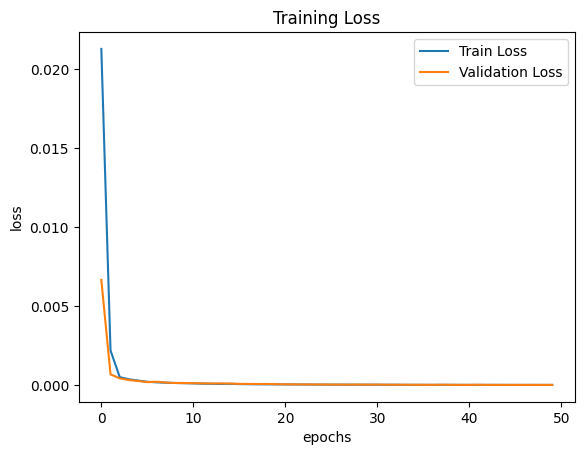

In [4]:
# 1. Generate a sequence (sine wave)
def generate_sequence(seq_length=5,num_samples=1000):
    X, y = [], []
    for i in range(num_samples):
        seq = np.random.rand(seq_length)
        X.append(seq)
        y.append(seq[-1]+0.1)
    return np.array(X), np.array(y)

# Generate data
seq_length = 5

X, y = generate_sequence(seq_length)


# Reshape for RNN: [samples, timesteps, features]
X = X.reshape((X.shape[0], seq_length , 1))

# Split into train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Build RNN model
model = Sequential([
    SimpleRNN(20, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

# 4. Compile model
model.compile(optimizer='adam', loss='mse')
model.summary()

# 5. Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

test_loss = model.evaluate(X_test, y_test)
print(f"Tets loss:{test_loss}")
# 6. Predictions
sample_input = np.array([0.1,0.2,0.3,0.4,0.5]).reshape(1,seq_length,1)
pred = model.predict(sample_input)
print(f"predicted next value: {pred}")

# 7. Plot results
'''plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("RNN Sequence Prediction")
plt.show()'''

# 8. Plot training loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.title("Training Loss")
plt.show()